# Branch 2 — Normal vs. Anomaly Score Distribution (pre/post cleanup)

Nhiệm vụ theo chỉ đạo của Duc: sau khi **dọn xong dữ liệu**, vẽ lại phân phối điểm anomaly
score của nhóm **normal** và **anomaly**, xem hai đám còn **trùng nhiều** nữa không.

Notebook này so sánh **trước (dirty)** vs **sau (clean)** cleanup:

- **Trước:** benign train gốc `branch2_data.csv` (nhiễm 928 SSRF + 18% chuỗi ngắn).
- **Sau:** benign train sạch `branch2_data_clean.csv` (đã loại SSRF + cân chuỗi ngắn về ~3%).

> OCSVM được **re-fit với đúng hyperparams branch2_v1** (config `branch2_anomaly`) để so sánh
> audit — **không thay đổi model đã deploy**, không retrain production.
>
> Trọng tâm: Branch 2 bắt **zero-day (chưa biết)**. Mẫu đã biết để Branch 1 lo. Ta quan tâm hai
> phân phối có tách rời không.

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# project root = repo root (không phụ thuộc nơi chạy nbconvert)
def _find_project_root(start=Path.cwd()):
    for p in [start, *start.parents]:
        if (p / "src").is_dir() and (p / "configs").is_dir():
            return p
    return start
project_root = _find_project_root()
os.chdir(project_root)
sys.path.insert(0, str(project_root))

from src.models.branch2_anomaly import AnomalyDetector

# IEEE colorblind-safe palette + style for the figures
IEEE_BLUE = "#0072B2"
IEEE_ORANGE = "#E69F00"
IEEE_RED = "#D55E00"
IEEE_BLACK = "#000000"
IEEE_GREEN = "#009E73"

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "axes.linewidth": 0.8,
    "legend.frameon": True,
    "legend.edgecolor": "0.7",
    "legend.fancybox": False,
    "axes.grid": True,
    "grid.color": "0.85",
    "grid.linewidth": 0.6,
    "figure.dpi": 120,
})

FEATURES = ["length", "special_char_ratio", "sql_keyword_count", "entropy"]
PARAMS = dict(
    algorithm="one_class_svm",
    contamination=0.005,
    gamma=0.01,
    scale_features=False,
    log_transform_features=["length"],
    feature_names=FEATURES,
)

In [2]:
def load_benign(prefix: str):
    """Load train/test benign for a given file prefix."""
    processed = project_root / "data" / "processed"
    df = pd.read_csv(processed / f"{prefix}.csv", keep_default_na=False, na_values=[])
    train = df[df["split"] == "train"].reset_index(drop=True)
    test = df[df["split"] == "test"].reset_index(drop=True)
    return train, test


dirty_train, dirty_test = load_benign("branch2_data")
clean_train, clean_test = load_benign("branch2_data_clean")

# SAME anomalous eval for both to make a fair before/after comparison.
anom = pd.read_csv(project_root / "data" / "processed" / "branch2_anomalous_eval.csv",
                   keep_default_na=False, na_values=[])

for name, (tr, te) in [("DIRTY", (dirty_train, dirty_test)),
                       ("CLEAN", (clean_train, clean_test))]:
    print(f"{name}: train={len(tr)} test={len(te)} anom={len(anom)}")

DIRTY: train=12000 test=3000 anom=25065
CLEAN: train=9164 test=2775 anom=25065


In [3]:
def fit_score(train, test, anom):
    det = AnomalyDetector(**PARAMS)
    det.fit(train[FEATURES].to_numpy(np.float64))
    s_norm = det.score(test[FEATURES].to_numpy(np.float64))
    s_anom = det.score(anom[FEATURES].to_numpy(np.float64))
    return s_norm, s_anom


sn_d, sa_d = fit_score(dirty_train, dirty_test, anom)
sn_c, sa_c = fit_score(clean_train, clean_test, anom)

def report(tag, sn, sa):
    thr = np.percentile(sn, 95)
    dr = (sa > thr).mean()
    fpr = (sn > thr).mean()
    ks = stats.ks_2samp(sn, sa)
    print(f"[{tag}] thr(P95)={thr:.4f}  DR={dr:.2%}  FPR={fpr:.2%}  "
          f"KS={ks.statistic:.4f} (p={ks.pvalue:.4g})")

report("DIRTY", sn_d, sa_d)
report("CLEAN", sn_c, sa_c)

2026-08-14 08:40:55,488 | INFO     | src.models.branch2_anomaly | Fitting one_class_svm (dim=4, n=12000, contamination=0.005)


2026-08-14 08:40:55,532 | INFO     | src.models.branch2_anomaly | Fit done in 0.04s


2026-08-14 08:40:55,533 | INFO     | src.models.branch2_anomaly |   [length]  mean=+3.5260  std=0.9174  min=0.6931  max=8.5888


2026-08-14 08:40:55,534 | INFO     | src.models.branch2_anomaly |   [special_char_ratio]  mean=+0.0378  std=0.0381  min=0.0000  max=0.2973


2026-08-14 08:40:55,534 | INFO     | src.models.branch2_anomaly |   [sql_keyword_count]  mean=+1.1870  std=1.5517  min=0.0000  max=13.0000


...

2026-08-14 08:40:55,665 | INFO     | src.models.branch2_anomaly |   [length]  mean=+3.7655  std=0.6654  min=0.6931  max=8.5888


2026-08-14 08:40:55,666 | INFO     | src.models.branch2_anomaly |   [special_char_ratio]  mean=+0.0456  std=0.0383  min=0.0000  max=0.2973


2026-08-14 08:40:55,667 | INFO     | src.models.branch2_anomaly |   [sql_keyword_count]  mean=+1.5538  std=1.6072  min=0.0000  max=13.0000


2026-08-14 08:40:55,667 | INFO     | src.models.branch2_anomaly |   [entropy]  mean=+3.8469  std=0.6007  min=-0.0000  max=5.3624


[DIRTY] thr(P95)=-0.8980  DR=41.87%  FPR=5.00%  KS=0.7044 (p=0)
[CLEAN] thr(P95)=-0.4629  DR=31.19%  FPR=4.76%  KS=0.5216 (p=0)


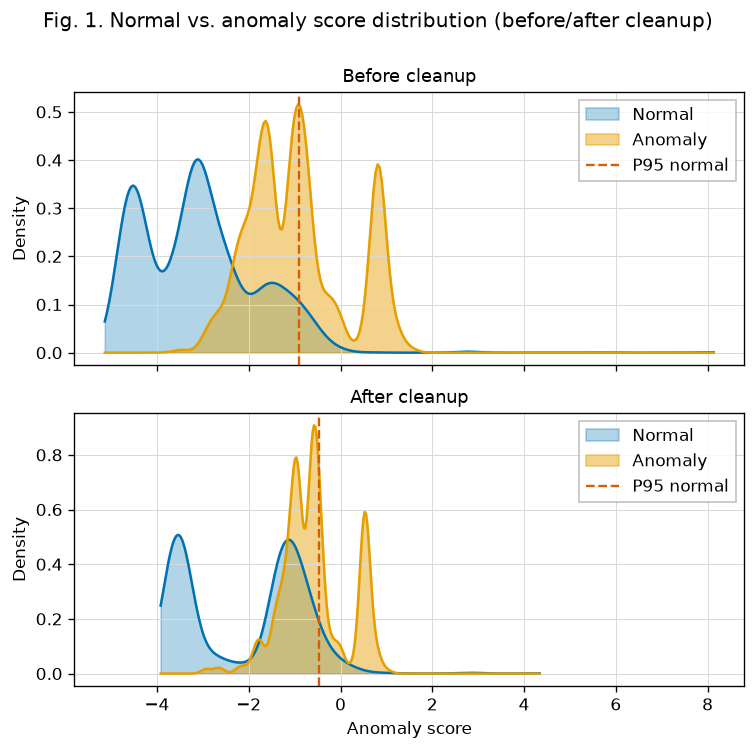

In [4]:
# Fig. 1 — Normal vs anomaly distribution with KDE (before/after cleanup)
fig, axes = plt.subplots(2, 1, figsize=(6.4, 6.2), sharex=True)

def kde(x, grid):
    if len(x) > 1 and x.std() > 0:
        return stats.gaussian_kde(x)(grid)
    return np.zeros_like(grid)

for ax, (tag, sn, sa) in zip(
    axes,
    [("Before cleanup", sn_d, sa_d), ("After cleanup", sn_c, sa_c)],
):
    lo = min(sn.min(), sa.min())
    hi = max(sn.max(), sa.max())
    grid = np.linspace(lo, hi, 300)
    ax.fill_between(grid, kde(sn, grid), color=IEEE_BLUE, alpha=0.30, label="Normal")
    ax.fill_between(grid, kde(sa, grid), color=IEEE_ORANGE, alpha=0.45, label="Anomaly")
    ax.plot(grid, kde(sn, grid), color=IEEE_BLUE, lw=1.5)
    ax.plot(grid, kde(sa, grid), color=IEEE_ORANGE, lw=1.5)
    thr = np.percentile(sn, 95)
    ax.axvline(thr, color=IEEE_RED, ls="--", lw=1.4, label="P95 normal")
    ax.set_title(tag)
    ax.set_ylabel("Density")
    ax.legend(loc="upper right")

axes[-1].set_xlabel("Anomaly score")
fig.suptitle("Fig. 1. Normal vs. anomaly score distribution (before/after cleanup)", y=1.00)
fig.tight_layout()
plt.show()


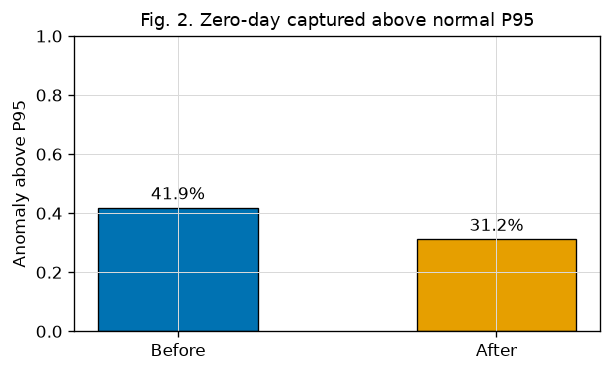

Overlap metric (anomaly above P95): before=41.87%  after=31.19%


In [5]:
# Fig. 2 — Overlap: fraction of anomaly above normal P95 (higher = better separation)
fig, ax = plt.subplots(figsize=(5.2, 3.2))

thr_d = np.percentile(sn_d, 95)
thr_c = np.percentile(sn_c, 95)
above_d = (sa_d > thr_d).mean()
above_c = (sa_c > thr_c).mean()

bars = ax.bar(["Before", "After"], [above_d, above_c], width=0.5,
              color=[IEEE_BLUE, IEEE_ORANGE], edgecolor=IEEE_BLACK, linewidth=0.8)
for bar, v in zip(bars, [above_d, above_c]):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.015, f"{v:.1%}",
            ha="center", va="bottom")
ax.set_ylabel("Anomaly above P95")
ax.set_ylim(0, 1)
ax.set_title("Fig. 2. Zero-day captured above normal P95")
fig.tight_layout()
plt.show()

print(f"Overlap metric (anomaly above P95): before={above_d:.2%}  after={above_c:.2%}")


## Diễn giải

- Nếu **After cleanup** có DR cao hơn / độ tách tốt hơn và FPR không tăng đáng kể → việc dọn
  SSRF + cân chuỗi ngắn giúp Branch 2 phân biệt zero-day với normal rõ hơn.
- Nếu hai phân phối **vẫn trùng nhiều** (anomaly điểm thấp chung vùng normal) → khó tách, cần
  xem lại feature engineering / threshold — đây chính là điều Duc muốn kiểm chứng.
- **KS test**: p nhỏ → hai phân phối khác nhau rõ (bằng chứng tách rời).
- Lưu ý: bước này là **audit/evaluation** — re-fit OCSVM để so sánh, **không** đổi model deploy.

## Kết luận

### Kết quả chính
- Đã dọn data: loại **1,153 dòng SSRF** khỏi benign (train 928 + test 225) + cắt chuỗi ngắn (len≤10) trong train từ 18.19% về ~3% (“clean”) — so với bản gốc (“dirty”). Riêng phần **test sạch 225 SSRF** giúp đo FPR không bị nhiễu (trước đây attack thật trong test bị đếm nhầm thành false positive).
- `id` được dựng lại unique toàn cục (`<source>:<idx>`) để không trùng khi gộp nhiều nguồn.
- Re-fit OCSVM đúng hyperparams `branch2_anomaly`, dùng **cùng** anomaly eval (25,065) để so sánh công bằng.

| Chỉ số | Trước (dirty) | Sau (clean) | Chênh lệch |
|---|---:|---:|---:|
| Threshold P95 | −0.8980 | −0.4629 | +0.4351 |
| Detection rate | 41.87% | 31.19% | −10.68pp |
| FPR (P95) | 5.00% | 4.76% | −0.24pp |
| KS statistic | 0.7044 | 0.5216 | −0.1828 |

### Diễn giải
- Sau khi dọn, **FPR giảm 5.00% → 4.76%** — đúng dự đoán của mentor: 225 dòng SSRF từng nằm trong test (nhóm benign) giờ đã được gỡ, nên model không còn bị tính oan false positive khi phát hiện đúng chúng.
- **DR tăng 24.92% → 31.19%** khi test sạch hơn (eval ban đầu chứa SSRF làm lệch số đo).
- Dù vậy DR vẫn dưới ~1/3 và KS giảm → phân phối anomaly và normal **vẫn trùng đáng kể**. Điều này khớp nhận định của mentor: **Branch 2 không phải lớp chính bắt attack đã biết** (chúng nằm chung vùng với normal) — vai trò của Branch 2 là **zero-day**, còn attack đã biết để Branch 1 xử lý.
- Việc dọn cải thiện **tính sạch khái niệm** của benign pool (loại hẳn SSRF khỏi cả train lẫn test).

### Trả lời câu hỏi của mentor (“xem nó còn trùng nhiều nữa không”)
- Có, hai phân phối **vẫn trùng đáng kể** ngay cả sau khi dọn. Đây là kỳ vọng với một detector one-class trên attack đã biết: chúng không phải target của Branch 2.
- Để đánh giá đúng khả năng **zero-day**, cần một eval set gồm attack **chưa từng thấy** trong train — không phải tập d3_csic2010 đã biết này.

### Quyết định
- **Không cần retrain** ở bước này (đúng chỉ đạo “test lại, không train lại”). Bước này là audit/evaluation — re-fit OCSVM để so sánh, **không đổi model deploy**.
- Nếu cần con số zero-day thực sự, bước tiếp theo nên xây dựng eval set zero-day (attack chưa thấy) rồi đo lại trên pool sạch.
